# Segmentacion de Cuerpos de Agua con Sentinel-2

Este notebook contiene el flujo completo del proyecto: preparacion del dataset, entrenamiento, validacion, test externo e inferencia final sobre escenas completas.

## Como leerlo y usarlo

1. Ajusta `cfg` en la seccion de configuracion.
2. Ejecuta las celdas de construccion de dataset para verificar cuantas escenas y parches entran.
3. Entrena el modelo y revisa las curvas de aprendizaje.
4. Evalua validacion y test para comparar experimentos.
5. Usa la seccion final de inferencia para probar escenas nuevas.

## Si quieres lanzar un nuevo experimento

Los cambios mas comunes se hacen en `cfg`:

- `dataset_folders`: para incluir nuevas carpetas de datos.
- `band_ids`, `band_names`, `spectral_indices`, `input_features`, `input_channels`: para cambiar bandas o indices.
- `batch_size`, `lr`, `weight_decay`, `epochs`: para ajustar entrenamiento.
- `train_stride`, `val_stride`, `min_water_ratio`, `empty_patch_keep_prob`: para cambiar como se generan los parches.

La idea es que cada bloque deje claro que entra, que sale y por que se hace.

Esta es la version base del flujo. En esta copia para Colab se agregan celdas de montaje de Drive y rutas adaptadas.


# Version para Google Colab

Esta copia del notebook esta pensada para ejecutarse en Google Colab sin tocar la version local del proyecto.

## Antes de correrlo

1. Sube o sincroniza la carpeta del proyecto a Google Drive.
2. Ajusta `COLAB_PROJECT_DIR` en la siguiente celda si tu ruta en Drive es diferente.
3. Verifica que dentro de esa carpeta exista `data/`, porque el dataset no esta en GitHub.


In [ ]:
# Solo para Google Colab
!pip install -q segmentation-models-pytorch rasterio

from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

# Ajusta esta ruta si tu proyecto esta en otra carpeta de Drive.
COLAB_PROJECT_DIR = Path("/content/drive/MyDrive/Xcalibur")
print("COLAB_PROJECT_DIR:", COLAB_PROJECT_DIR)
print("Existe proyecto:", COLAB_PROJECT_DIR.exists())


## 1. Configuracion General

En esta seccion se cargan librerias, se definen las rutas del proyecto y se crea el diccionario `cfg`, que es el centro de configuracion de toda la corrida.

### Que conviene tocar aqui

- Rutas base si cambias la estructura del proyecto.
- Hiperparametros del experimento.
- Bandas e indices espectrales.
- Nombre automatico del experimento y carpetas de salida.

### Que sale de esta seccion

- `cfg` listo para usarse en train, validacion, test e inferencia.
- Carpetas de salida creadas para guardar pesos, metricas y graficas.
- `device` detectado automaticamente.


In [1]:
from pathlib import Path
from datetime import datetime
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

# --- Rutas base del proyecto ---
if "COLAB_PROJECT_DIR" in globals():
    PROJECT_DIR = Path(COLAB_PROJECT_DIR)
elif Path.cwd().name == "notebook":
    PROJECT_DIR = Path.cwd().parent
else:
    PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
WEIGHTS_DIR = PROJECT_DIR / "weights"
EXPERIMENTS_DIR = PROJECT_DIR / "experiments"
PART5_DIR = DATA_DIR / "part5"

dataset_folders = ["dset-s2", "extra_folder_1", "extra_folder_2"]

cfg = {
    "dataset_folders": dataset_folders,
    "train_img_subdir": "tra_scene",
    "train_mask_subdir": "tra_truth",
    "val_img_subdir": "val_scene",
    "val_mask_subdir": "val_truth",
    
    # Parámetros del parche y bandas / índices usados en la corrida
    "patch_size": 256,
    "train_stride": 128,
    "val_stride": 256,
    "band_ids": [1, 2, 3, 4, 5, 6],
    "band_names": ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"],
    "spectral_indices": ["MNDWI"],
    "input_features": ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "MNDWI"],
    "input_channels": 7,
    "architecture": "Unet",
    "encoder_name": "resnet34",
    
    # Hiperparámetros de entrenamiento
    "batch_size": 16,
    "epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": 0,
    "min_water_ratio": 0.001,
    "empty_patch_keep_prob": 0.20,
    
    # Early stopping y Scheduler (ReduceLROnPlateau)
    "early_stopping_patience": 6,
    "early_stopping_min_delta": 1e-4,
    "lr_patience": 2,
    "lr_factor": 0.5,
    "seed": 42,
    
    # Tracking de experimentos
    "experiment_name": f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
}

cfg["experiment_dir"] = EXPERIMENTS_DIR / cfg["experiment_name"]
cfg["model_path"] = cfg["experiment_dir"] / "best_model.pth"
cfg["history_path"] = cfg["experiment_dir"] / "history.csv"
cfg["config_path"] = cfg["experiment_dir"] / "config.json"
cfg["val_metrics_path"] = cfg["experiment_dir"] / "val_metrics.csv"
cfg["learning_curve_path"] = cfg["experiment_dir"] / "learning_curves.png"
cfg["confusion_matrix_path"] = cfg["experiment_dir"] / "confusion_matrix.png"
cfg["pr_curve_path"] = cfg["experiment_dir"] / "precision_recall_curve.png"
cfg["test_dir"] = cfg["experiment_dir"] / "test_part5"
cfg["test_metrics_path"] = cfg["test_dir"] / "test_metrics_part5.csv"
cfg["test_global_metrics_path"] = cfg["test_dir"] / "test_global_metrics_part5.csv"
cfg["test_confusion_matrix_path"] = cfg["test_dir"] / "test_confusion_matrix_part5.png"
cfg["test_pr_curve_path"] = cfg["test_dir"] / "test_precision_recall_curve_part5.png"
cfg["test_diagnostic_scene_path"] = cfg["test_dir"] / "test_scene_diagnostic_part5.png"
cfg["experiment_dir"].mkdir(parents=True, exist_ok=True)
cfg["test_dir"].mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)


def build_run_summary(cfg):
    features_txt = ", ".join(cfg.get("input_features", []))
    return (
        f"{cfg['architecture']} + {cfg['encoder_name']} | "
        f"patch={cfg['patch_size']} | batch={cfg['batch_size']} | "
        f"lr={cfg['lr']} | wd={cfg['weight_decay']} | "
        f"train_stride={cfg['train_stride']} | val_stride={cfg['val_stride']}\n"
        f"features={features_txt} | channels={cfg['input_channels']}"
    )


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


c:\Users\Daniel Ortiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 2. Utilidades para Escenas y Parches

Aqui se definen funciones auxiliares para emparejar imagenes con mascaras, recorrer escenas grandes y convertirlas en ventanas `256x256`.

### Idea clave

El modelo no ve escenas completas durante entrenamiento. Ve parches, por eso este bloque controla como se parte cada imagen y como se evita llenar el dataset con demasiado fondo vacio.

### Si quieres probar otro experimento

- Cambia `patch_size` y `stride` desde `cfg`.
- Ajusta `min_water_ratio` si quieres ser mas estricto con parches utiles.
- Ajusta `empty_patch_keep_prob` si notas demasiado desbalance hacia tierra.


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def mask_name_from_img(img_path):
    return img_path.name.replace("_6Bands_", "_").replace(".tif", "_Truth.tif")


def collect_pairs(img_dir, mask_dir):
    pairs = []
    for img_path in sorted(img_dir.glob("*.tif")):
        mask_path = mask_dir / mask_name_from_img(img_path)
        if not mask_path.exists():
            continue

        with rasterio.open(img_path) as img_src, rasterio.open(mask_path) as mask_src:
            same_shape = (img_src.height == mask_src.height) and (img_src.width == mask_src.width)

        if same_shape:
            pairs.append((img_path, mask_path))
    return pairs


def build_positions(size, patch_size, stride):
    if size <= patch_size:
        return [0]

    pos = list(range(0, size - patch_size + 1, stride))
    last = size - patch_size
    if pos[-1] != last:
        pos.append(last)
    return pos


def build_samples(
    pairs,
    patch_size,
    stride,
    filter_empty=False,
    min_water_ratio=0.001,
    empty_patch_keep_prob=0.20,
):
    samples = []
    for img_path, mask_path in pairs:
        with rasterio.open(img_path) as src:
            rows = build_positions(src.height, patch_size, stride)
            cols = build_positions(src.width, patch_size, stride)

        if not filter_empty:
            for row in rows:
                for col in cols:
                    samples.append((img_path, mask_path, row, col))
            continue

        with rasterio.open(mask_path) as src:
            for row in rows:
                for col in cols:
                    window = Window(col_off=col, row_off=row, width=patch_size, height=patch_size)
                    mask = src.read(1, window=window)
                    water_ratio = float((mask > 0).mean())

                    # Guardamos todos los parches con agua y solo una parte de los vacios.
                    if water_ratio >= min_water_ratio or random.random() < empty_patch_keep_prob:
                        samples.append((img_path, mask_path, row, col))
    return samples


set_seed(cfg["seed"])


## 3. Dataset de PyTorch y Aumentaciones

Esta celda define `WaterDataset`, que lee cada parche desde disco, normaliza reflectancia, calcula `MNDWI`, prepara la mascara y aplica aumentaciones solo cuando `is_train=True`.

### Que hace exactamente

- Lee las bandas crudas desde el GeoTIFF.
- Divide por `10000.0` para llevarlas a reflectancia aproximada.
- Construye los canales finales que vera la red.
- Convierte la mascara a binaria con forma `[1, H, W]`.
- En entrenamiento aplica flips, rotaciones y cambios radiometricos suaves.

### Ojo para futuros cambios

Si cambias las bandas o el indice espectral, este es uno de los bloques que debes revisar primero.


In [3]:
class WaterDataset(Dataset):
    def __init__(self, samples, patch_size=256, band_ids=None, is_train=False):
        self.samples = samples
        self.patch_size = patch_size
        self.band_ids = band_ids or [1, 2, 3, 4, 5, 6]
        self.is_train = is_train

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, row, col = self.samples[idx]
        window = Window(col_off=col, row_off=row, width=self.patch_size, height=self.patch_size)

        with rasterio.open(img_path) as src:
            img = src.read(self.band_ids, window=window).astype(np.float32)

        with rasterio.open(mask_path) as src:
            mask = src.read(1, window=window).astype(np.float32)

        # Sentinel-2 suele venir escalado en reflectancia * 10000.
        img = img / 10000.0

        blue = img[0]
        green = img[1]
        red = img[2]
        nir = img[3]
        swir1 = img[4]
        swir2 = img[5]

        # MNDWI ayuda a resaltar agua usando Green y SWIR1.
        mndwi = (green - swir1) / (green + swir1 + 1e-6)

        img = np.stack([blue, green, red, nir, swir1, swir2, mndwi], axis=0)

        # La mascara tiene que quedar en [1, H, W] para BCE y Dice.
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        if self.is_train:
            # Flips Geométricos
            if random.random() < 0.5:
                img = np.flip(img, axis=2).copy()
                mask = np.flip(mask, axis=2).copy()

            if random.random() < 0.5:
                img = np.flip(img, axis=1).copy()
                mask = np.flip(mask, axis=1).copy()

            if random.random() < 0.5:
                k = random.randint(1, 3)
                img = np.rot90(img, k=k, axes=(1, 2)).copy()
                mask = np.rot90(mask, k=k, axes=(1, 2)).copy()

            # Aumentación radiométrica: afecta a las 6 bandas crudas [:6] y recalcula MNDWI en la 7 [6]
            if random.random() < 0.5:
                scale = random.uniform(0.90, 1.10)
                img[:6] = np.clip(img[:6] * scale, 0.0, 1.0)
                img[6] = (img[1] - img[4]) / (img[1] + img[4] + 1e-6)

            if random.random() < 0.3:
                noise = np.random.normal(0.0, 0.01, size=img[:6].shape).astype(np.float32)
                img[:6] = np.clip(img[:6] + noise, 0.0, 1.0)
                img[6] = (img[1] - img[4]) / (img[1] + img[4] + 1e-6)

        return torch.from_numpy(img), torch.from_numpy(mask)


## 4. Construccion de Train y Validation

En este bloque se recorren las carpetas declaradas en `dataset_folders`, se construyen los pares imagen-mascara, se generan los parches y luego se crean los `DataLoader`.

### Que revisar aqui antes de entrenar

- Numero de escenas de train y validation.
- Numero total de parches generados.
- `train water ratio` para entender el desbalance.
- `pos_weight` usado por `BCEWithLogitsLoss`.

### Si el experimento cambia mucho

Si agregas carpetas nuevas o modificas la estrategia de muestreo, aqui deberias ver el impacto inmediatamente.


In [4]:
train_pairs = []
val_pairs = []

for folder_name in cfg["dataset_folders"]:
    folder_root = DATA_DIR / folder_name

    train_img_dir = folder_root / cfg["train_img_subdir"]
    train_mask_dir = folder_root / cfg["train_mask_subdir"]
    val_img_dir = folder_root / cfg["val_img_subdir"]
    val_mask_dir = folder_root / cfg["val_mask_subdir"]

    if train_img_dir.exists() and train_mask_dir.exists():
        train_pairs.extend(collect_pairs(train_img_dir, train_mask_dir))

    if val_img_dir.exists() and val_mask_dir.exists():
        val_pairs.extend(collect_pairs(val_img_dir, val_mask_dir))

train_samples = build_samples(
    train_pairs,
    cfg["patch_size"],
    cfg["train_stride"],
    filter_empty=True,
    min_water_ratio=cfg["min_water_ratio"],
    empty_patch_keep_prob=cfg["empty_patch_keep_prob"],
)
val_samples = build_samples(val_pairs, cfg["patch_size"], cfg["val_stride"])

print("train scenes:", len(train_pairs))
print("val scenes:", len(val_pairs))
print("train patches:", len(train_samples))
print("val patches:", len(val_samples))

water_pixels = 0
total_pixels = 0
for _, mask_path, row, col in train_samples:
    window = Window(col_off=col, row_off=row, width=cfg["patch_size"], height=cfg["patch_size"])
    with rasterio.open(mask_path) as src:
        mask = src.read(1, window=window)
    water_pixels += int((mask > 0).sum())
    total_pixels += int(mask.size)

water_ratio = water_pixels / max(total_pixels, 1)
neg_pixels = total_pixels - water_pixels
cfg["pos_weight"] = float(neg_pixels / max(water_pixels, 1))

print("train water ratio:", round(water_ratio, 6))
print("bce pos_weight:", round(cfg["pos_weight"], 4))

train_ds = WaterDataset(train_samples, patch_size=cfg["patch_size"], band_ids=cfg["band_ids"], is_train=True)
val_ds = WaterDataset(val_samples, patch_size=cfg["patch_size"], band_ids=cfg["band_ids"], is_train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg["batch_size"],
    shuffle=True,
    num_workers=cfg["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg["batch_size"],
    shuffle=False,
    num_workers=cfg["num_workers"],
    pin_memory=torch.cuda.is_available(),
)


train scenes: 64
val scenes: 31
train patches: 3115
val patches: 522
train water ratio: 0.275507
bce pos_weight: 2.6297


## 5. Modelo, Loss y Optimizacion

Aqui se instancia la `U-Net` con backbone `resnet34`, siempre con `encoder_weights=None`, tal como exige el reto.

### Componentes principales

- Modelo: `smp.Unet`
- Loss: `0.5 * BCEWithLogitsLoss + 0.5 * DiceLoss`
- Optimizador: `Adam`
- Regularizacion: `weight_decay`
- Scheduler: `ReduceLROnPlateau`
- Estabilidad numerica: `GradScaler` y `autocast`

### Si quieres hacer otro experimento

Este es el lugar para cambiar `lr`, `weight_decay` o incluso probar otro backbone, siempre que siga siendo valido para el reto.


In [5]:
model = smp.Unet(
    encoder_name=cfg["encoder_name"],
    encoder_weights=None,
    in_channels=cfg["input_channels"],
    classes=1,
)
model = model.to(device)

pos_weight = torch.tensor([cfg["pos_weight"]], dtype=torch.float32, device=device)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)

# weight_decay mete una penalizacion suave para no sobreajustar tanto.
optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=cfg["lr_factor"],
    patience=cfg["lr_patience"],
)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())


def calc_loss(logits, mask):
    bce = bce_loss(logits, mask)
    dice = dice_loss(logits, mask)
    loss = 0.5 * bce + 0.5 * dice
    return loss, bce, dice


def calc_metrics(logits, mask, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    pred = (probs > thr).float()

    pred = pred.view(pred.size(0), -1)
    mask = mask.view(mask.size(0), -1)

    inter = (pred * mask).sum(dim=1)
    union = pred.sum(dim=1) + mask.sum(dim=1) - inter
    dice = (2 * inter + eps) / (pred.sum(dim=1) + mask.sum(dim=1) + eps)
    iou = (inter + eps) / (union + eps)

    return dice.mean().item(), iou.mean().item()


## 6. Loop de Entrenamiento por Epoca

Esta funcion ejecuta una epoca completa sobre un `DataLoader`, tanto en entrenamiento como en validacion.

### Que calcula

- `loss`
- `bce`
- `dice_loss`
- `dice`
- `iou`

La funcion devuelve promedios por epoca, que luego se guardan en `history_df`.


In [6]:
def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_bce = 0.0
    total_dice_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    pbar = tqdm(loader, leave=False)
    for img, mask in pbar:
        img = img.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(img)
                loss, bce, dice_part = calc_loss(logits, mask)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

        dice_score, iou_score = calc_metrics(logits.detach(), mask.detach())

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice_loss += dice_part.item()
        total_dice += dice_score
        total_iou += iou_score

        pbar.set_description(f"loss={loss.item():.4f} dice={dice_score:.4f} iou={iou_score:.4f}")

    n = len(loader)
    return {
        "loss": total_loss / n,
        "bce": total_bce / n,
        "dice_loss": total_dice_loss / n,
        "dice": total_dice / n,
        "iou": total_iou / n,
    }


## 7. Entrenamiento Completo y Guardado del Experimento

Aqui se ejecuta el ciclo principal de entrenamiento. En cada epoca se entrena, se valida, se actualiza el scheduler y se decide si el modelo actual mejora o no.

### Que se guarda

- Mejor checkpoint segun `val_iou`
- `history.csv`
- `config.json`

### Por que es importante

Esta seccion es la que deja trazabilidad real del experimento. Si luego comparas corridas, casi todo sale de lo que se guarda aqui.


In [7]:
history = []
best_iou = -1.0
epochs_without_improving = 0

for epoch in range(1, cfg["epochs"] + 1):
    train_metrics = run_epoch(train_loader, model, optimizer=optimizer)
    with torch.no_grad():
        val_metrics = run_epoch(val_loader, model, optimizer=None)

    scheduler.step(val_metrics["iou"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_bce": train_metrics["bce"],
        "train_dice_loss": train_metrics["dice_loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_loss": val_metrics["loss"],
        "val_bce": val_metrics["bce"],
        "val_dice_loss": val_metrics["dice_loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "lr": optimizer.param_groups[0]["lr"],
        "epochs_without_improving": epochs_without_improving,
    }
    history.append(row)

    print(
        f"epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} train_dice={row['train_dice']:.4f} train_iou={row['train_iou']:.4f} | "
        f"val_loss={row['val_loss']:.4f} val_dice={row['val_dice']:.4f} val_iou={row['val_iou']:.4f}"
    )

    if row["val_iou"] > best_iou + cfg["early_stopping_min_delta"]:
        best_iou = row["val_iou"]
        epochs_without_improving = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "cfg": cfg,
                "epoch": epoch,
                "val_iou": row["val_iou"],
                "val_dice": row["val_dice"],
            },
            cfg["model_path"],
        )
        print(f"mejor modelo guardado en {cfg['model_path']} con val_iou={best_iou:.4f}")
    else:
        epochs_without_improving += 1
        print(f"sin mejora clara en val_iou por {epochs_without_improving} epocas")

    if epochs_without_improving >= cfg["early_stopping_patience"]:
        print(f"early stopping en epoch {epoch:02d} por falta de mejora en validacion")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(cfg["history_path"], index=False)

cfg_to_save = {}
for key, value in cfg.items():
    if isinstance(value, Path):
        cfg_to_save[key] = str(value)
    else:
        cfg_to_save[key] = value

with open(cfg["config_path"], "w", encoding="utf-8") as f:
    json.dump(cfg_to_save, f, indent=2, ensure_ascii=False)

print("experimento guardado en:", cfg["experiment_dir"])
print("history:", cfg["history_path"])
print("config:", cfg["config_path"])
print("best model:", cfg["model_path"])

history_df.tail()


epoch 01 | train_loss=0.1865 train_dice=0.8020 train_iou=0.7319 | val_loss=0.1662 val_dice=0.6789 val_iou=0.6197
mejor modelo guardado en c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\best_model.pth con val_iou=0.6197


epoch 02 | train_loss=0.1184 train_dice=0.8418 train_iou=0.7791 | val_loss=0.0899 val_dice=0.7248 val_iou=0.6751
mejor modelo guardado en c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\best_model.pth con val_iou=0.6751


epoch 03 | train_loss=0.0981 train_dice=0.8551 train_iou=0.7952 | val_loss=0.0738 val_dice=0.7429 val_iou=0.6957
mejor modelo guardado en c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\best_model.pth con val_iou=0.6957


epoch 04 | train_loss=0.0837 train_dice=0.8638 train_iou=0.8062 | val_loss=0.0931 val_dice=0.7376 val_iou=0.6885
sin mejora clara en val_iou por 1 epocas


epoch 05 | train_loss=0.0803 train_dice=0.8694 train_iou=0.8123 | val_loss=0.0790 val_dice=0.7413 val_iou=0.6946
sin mejora clara en val_iou por 2 epocas


...

epoch 14 | train_loss=0.0560 train_dice=0.8933 train_iou=0.8413 | val_loss=0.0538 val_dice=0.7529 val_iou=0.7066
sin mejora clara en val_iou por 3 epocas


epoch 15 | train_loss=0.0521 train_dice=0.8974 train_iou=0.8468 | val_loss=0.0486 val_dice=0.7632 val_iou=0.7174
sin mejora clara en val_iou por 4 epocas


epoch 16 | train_loss=0.0515 train_dice=0.8991 train_iou=0.8485 | val_loss=0.0563 val_dice=0.7458 val_iou=0.6989
sin mejora clara en val_iou por 5 epocas


epoch 17 | train_loss=0.0511 train_dice=0.8987 train_iou=0.8486 | val_loss=0.0591 val_dice=0.7373 val_iou=0.6903
sin mejora clara en val_iou por 6 epocas
early stopping en epoch 17 por falta de mejora en validacion
experimento guardado en: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116
history: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\history.csv
config: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\config.json
best model: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\best_model.pth


,epoch,train_loss,train_bce,train_dice_loss,train_dice,train_iou,val_loss,val_bce,val_dice_loss,val_dice,val_iou,lr,epochs_without_improving
12,13,0.057976,0.072978,0.042973,0.892866,0.841304,0.051857,0.038143,0.065571,0.761102,0.716119,0.000500,1
13,14,0.056015,0.070228,0.041802,0.893316,0.841260,0.053758,0.041003,0.066513,0.752926,0.706646,0.000250,2
14,15,0.052081,0.064592,0.039570,0.897388,0.846828,0.048557,0.036226,0.060888,0.763174,0.717427,0.000250,3
15,16,0.051543,0.063932,0.039153,0.899069,0.848544,0.056306,0.042219,0.070393,0.745757,0.698878,0.000250,4
16,17,0.051084,0.063636,0.038532,0.898661,0.848552,0.059091,0.040907,0.077275,0.737253,0.690280,0.000125,5


## 8. Funciones de Inferencia y Evaluacion Espacial

Este bloque reutiliza el mejor modelo guardado para reconstruir escenas completas a partir de ventanas deslizantes.

### Flujo general

1. Cargar checkpoint.
2. Leer imagen por ventanas.
3. Preprocesar bandas igual que en entrenamiento.
4. Predecir cada parche.
5. Reconstruir la escena completa acumulando probabilidades.
6. Umbralizar para obtener la mascara final.

Estas funciones son la base tanto de la inferencia final como del test en `part5`.


In [8]:
def load_model_for_inference(model_path, device):
    # El checkpoint es local y lo generamos nosotros en entrenamiento.
    ckpt = torch.load(model_path, map_location=device, weights_only=False)

    model_cfg = ckpt.get("cfg", {})
    band_ids = model_cfg.get("band_ids", cfg["band_ids"])

    model = smp.Unet(
        encoder_name=model_cfg.get("encoder_name", cfg["encoder_name"]),
        encoder_weights=None,
        in_channels=model_cfg.get("input_channels", cfg["input_channels"]),
        classes=1,
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model, band_ids, model_cfg


def preprocess_patch(img_patch):
    img_patch = img_patch.astype(np.float32) / 10000.0

    blue = img_patch[0]
    green = img_patch[1]
    red = img_patch[2]
    nir = img_patch[3]
    swir1 = img_patch[4]
    swir2 = img_patch[5]

    mndwi = (green - swir1) / (green + swir1 + 1e-6)
    img_patch = np.stack([blue, green, red, nir, swir1, swir2, mndwi], axis=0)

    return img_patch


def predict_tif(
    img_path,
    model,
    device,
    band_ids,
    patch_size=256,
    stride=256,
    threshold=0.5,
    out_path=None,
    prob_out_path=None,
):
    img_path = Path(img_path)

    with rasterio.open(img_path) as src:
        height, width = src.height, src.width
        rows = build_positions(height, patch_size, stride)
        cols = build_positions(width, patch_size, stride)

        prob_sum = np.zeros((height, width), dtype=np.float32)
        count_sum = np.zeros((height, width), dtype=np.float32)
        meta = src.meta.copy()

        with torch.no_grad():
            for row in tqdm(rows, desc=f"infer {img_path.name}", leave=False):
                for col in cols:
                    window = Window(col_off=col, row_off=row, width=patch_size, height=patch_size)
                    img_patch = src.read(band_ids, window=window)
                    img_patch = preprocess_patch(img_patch)

                    x = torch.from_numpy(img_patch).unsqueeze(0).to(device)
                    with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                        logits = model(x)
                        probs = torch.sigmoid(logits).squeeze().detach().cpu().numpy()

                    row_end = row + patch_size
                    col_end = col + patch_size
                    prob_sum[row:row_end, col:col_end] += probs
                    count_sum[row:row_end, col:col_end] += 1.0

    prob_map = prob_sum / np.clip(count_sum, a_min=1e-6, a_max=None)
    pred_mask = (prob_map >= threshold).astype(np.uint8)

    if out_path is not None:
        out_path = Path(out_path)
        meta_mask = meta.copy()
        meta_mask.update(count=1, dtype="uint8")
        with rasterio.open(out_path, "w", **meta_mask) as dst:
            dst.write(pred_mask, 1)

    if prob_out_path is not None:
        prob_out_path = Path(prob_out_path)
        meta_prob = meta.copy()
        meta_prob.update(count=1, dtype="float32")
        with rasterio.open(prob_out_path, "w", **meta_prob) as dst:
            dst.write(prob_map.astype(np.float32), 1)

    return prob_map, pred_mask


def evaluate_mask_with_valid(pred_mask, true_mask, valid_mask, threshold=0.5):
    valid = valid_mask > 0
    y_true = true_mask[valid].astype(np.uint8)
    y_pred = pred_mask[valid].astype(np.uint8)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    iou = tp / max(tp + fp + fn, 1)
    dice = (2 * tp) / max(2 * tp + fp + fn, 1)

    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "valid_pixels": int(valid.sum()),
        "water_pixels": int(y_true.sum()),
        "pred_water_pixels": int(y_pred.sum()),
    }


def evaluate_part5_scene(scene_dir, model, device, band_ids, patch_size=256, stride=256, threshold=0.5, out_dir=None):
    scene_dir = Path(scene_dir)
    scene_id = scene_dir.name
    img_path = scene_dir / f"sentinel12_s2_{scene_id}_img.tif"
    msk_path = scene_dir / f"sentinel12_s2_{scene_id}_msk.tif"
    valid_path = scene_dir / f"sentinel12_s2_{scene_id}_valid.tif"

    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"part5_{scene_id}_pred_mask.tif"
        prob_out_path = out_dir / f"part5_{scene_id}_prob_map.tif"
    else:
        out_path = None
        prob_out_path = None

    prob_map, pred_mask = predict_tif(
        img_path=img_path,
        model=model,
        device=device,
        band_ids=band_ids,
        patch_size=patch_size,
        stride=stride,
        threshold=threshold,
        out_path=out_path,
        prob_out_path=prob_out_path,
    )

    with rasterio.open(msk_path) as src:
        true_mask = src.read(1)

    with rasterio.open(valid_path) as src:
        valid_mask = src.read(1)

    metrics = evaluate_mask_with_valid(pred_mask, true_mask, valid_mask, threshold=threshold)
    metrics["scene_id"] = scene_id
    metrics["img_path"] = str(img_path)
    metrics["pred_path"] = str(out_path) if out_path is not None else ""
    metrics["prob_path"] = str(prob_out_path) if prob_out_path is not None else ""

    return metrics, prob_map, pred_mask, true_mask, valid_mask



## 9. Graficas y Metricas de Validacion y Test

Aqui se agrupan funciones para resumir el rendimiento del experimento de una forma visual y comparable.

### Salidas principales

- Curvas de aprendizaje.
- Matriz de confusion por pixel.
- Curva precision-recall.
- Metricas globales como `IoU`, `Dice`, `precision` y `recall`.



In [9]:
def plot_learning_curves(history_df, cfg):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_iou"], label="train_iou")
    axes[1].plot(history_df["epoch"], history_df["val_iou"], label="val_iou")
    axes[1].set_title("IoU Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("IoU")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.suptitle("Learning Curves", fontsize=14, y=1.04)
    fig.text(0.5, 0.98, build_run_summary(cfg), ha="center", va="top", fontsize=9)
    plt.tight_layout()
    fig.savefig(cfg["learning_curve_path"], dpi=200, bbox_inches="tight")
    plt.show()


def evaluate_classification_metrics(loader, model, threshold=0.5):
    model.eval()

    all_probs = []
    all_mask = []

    with torch.no_grad():
        for img, mask in tqdm(loader, leave=False):
            img = img.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(img)
                probs = torch.sigmoid(logits)

            all_probs.append(probs.detach().cpu().numpy().reshape(-1))
            all_mask.append(mask.numpy().reshape(-1))

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_mask).astype(np.uint8)
    y_pred = (y_prob >= threshold).astype(np.uint8)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    iou = tp / max(tp + fp + fn, 1)
    dice = (2 * tp) / max(2 * tp + fp + fn, 1)

    thresholds = np.linspace(0.0, 1.0, 101)
    pr_points = []
    for thr in thresholds:
        pred_thr = (y_prob >= thr).astype(np.uint8)
        tp_thr = ((pred_thr == 1) & (y_true == 1)).sum()
        fp_thr = ((pred_thr == 1) & (y_true == 0)).sum()
        fn_thr = ((pred_thr == 0) & (y_true == 1)).sum()

        precision_thr = tp_thr / max(tp_thr + fp_thr, 1)
        recall_thr = tp_thr / max(tp_thr + fn_thr, 1)
        pr_points.append((recall_thr, precision_thr))

    pr_points = np.array(pr_points)
    order = np.argsort(pr_points[:, 0])
    recall_curve = pr_points[order, 0]
    precision_curve = pr_points[order, 1]
    pr_auc = np.trapezoid(precision_curve, recall_curve)

    metrics = {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "pr_auc": pr_auc,
    }

    curves = {
        "recall": recall_curve,
        "precision": precision_curve,
    }

    return metrics, curves


def plot_confusion_matrix(metrics, cfg):
    cm = np.array([
        [metrics["tn"], metrics["fp"]],
        [metrics["fn"], metrics["tp"]],
    ], dtype=np.int64)

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Matriz de Confusion")
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1], labels=["No agua", "Agua"])
    ax.set_yticks([0, 1], labels=["No agua", "Agua"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black")

    fig.suptitle("Validacion | Clasificacion por pixel", fontsize=14, y=1.02)
    fig.text(0.5, 0.96, build_run_summary(cfg), ha="center", va="top", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(cfg["confusion_matrix_path"], dpi=200, bbox_inches="tight")
    plt.show()


def plot_precision_recall_curve(curves, metrics, cfg):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(curves["recall"], curves["precision"], linewidth=2)
    ax.set_title(f"Precision-Recall Curve | AUC={metrics['pr_auc']:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.3)
    fig.text(0.5, 0.98, build_run_summary(cfg), ha="center", va="top", fontsize=9)
    plt.tight_layout()
    fig.savefig(cfg["pr_curve_path"], dpi=200, bbox_inches="tight")
    plt.show()


def collect_part5_probabilities(scene_dirs, model, device, band_ids, patch_size=256, stride=256, cache_dir=None):
    all_probs = []
    all_true = []

    for scene_dir in scene_dirs:
        scene_dir = Path(scene_dir)
        scene_id = scene_dir.name
        img_path = scene_dir / f"sentinel12_s2_{scene_id}_img.tif"
        msk_path = scene_dir / f"sentinel12_s2_{scene_id}_msk.tif"
        valid_path = scene_dir / f"sentinel12_s2_{scene_id}_valid.tif"

        prob_map = None
        if cache_dir is not None:
            prob_cache_path = Path(cache_dir) / f"part5_{scene_id}_prob_map.tif"
            if prob_cache_path.exists():
                with rasterio.open(prob_cache_path) as src:
                    prob_map = src.read(1).astype(np.float32)

        if prob_map is None:
            prob_map, _ = predict_tif(
                img_path=img_path,
                model=model,
                device=device,
                band_ids=band_ids,
                patch_size=patch_size,
                stride=stride,
                threshold=0.5,
                out_path=None,
                prob_out_path=prob_cache_path if cache_dir is not None else None,
            )

        with rasterio.open(msk_path) as src:
            true_mask = src.read(1)
        with rasterio.open(valid_path) as src:
            valid_mask = src.read(1)

        valid = valid_mask > 0
        all_probs.append(prob_map[valid].reshape(-1))
        all_true.append(true_mask[valid].astype(np.uint8).reshape(-1))

    return np.concatenate(all_probs), np.concatenate(all_true)


def build_metrics_from_probabilities(y_prob, y_true, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(np.uint8)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    iou = tp / max(tp + fp + fn, 1)
    dice = (2 * tp) / max(2 * tp + fp + fn, 1)

    thresholds = np.linspace(0.0, 1.0, 101)
    pr_points = []
    for thr in thresholds:
        pred_thr = (y_prob >= thr).astype(np.uint8)
        tp_thr = ((pred_thr == 1) & (y_true == 1)).sum()
        fp_thr = ((pred_thr == 1) & (y_true == 0)).sum()
        fn_thr = ((pred_thr == 0) & (y_true == 1)).sum()

        precision_thr = tp_thr / max(tp_thr + fp_thr, 1)
        recall_thr = tp_thr / max(tp_thr + fn_thr, 1)
        pr_points.append((recall_thr, precision_thr))

    pr_points = np.array(pr_points)
    order = np.argsort(pr_points[:, 0])
    recall_curve = pr_points[order, 0]
    precision_curve = pr_points[order, 1]
    pr_auc = np.trapezoid(precision_curve, recall_curve)

    metrics = {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "pr_auc": pr_auc,
    }

    curves = {"recall": recall_curve, "precision": precision_curve}
    return metrics, curves


def plot_test_confusion_matrix(metrics, cfg):
    cm = np.array([[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]], dtype=np.int64)
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Test Part5 | Matriz de Confusion")
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1], labels=["No agua", "Agua"])
    ax.set_yticks([0, 1], labels=["No agua", "Agua"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black")
    fig.text(0.5, 0.98, build_run_summary(cfg), ha="center", va="top", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(cfg["test_confusion_matrix_path"], dpi=200, bbox_inches="tight")
    plt.show()


def plot_test_precision_recall_curve(curves, metrics, cfg):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(curves["recall"], curves["precision"], linewidth=2)
    ax.set_title(f"Test Part5 | Precision-Recall | AUC={metrics['pr_auc']:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.3)
    fig.text(0.5, 0.98, build_run_summary(cfg), ha="center", va="top", fontsize=9)
    plt.tight_layout()
    fig.savefig(cfg["test_pr_curve_path"], dpi=200, bbox_inches="tight")
    plt.show()


def plot_test_scene_diagnostics(scene_dir, model, device, band_ids, cfg, threshold=0.5):
    import matplotlib.patches as mpatches

    scene_dir = Path(scene_dir)
    scene_id = scene_dir.name
    metrics_scene, prob_map, pred_mask, true_mask, valid_mask = evaluate_part5_scene(
        scene_dir=scene_dir,
        model=model,
        device=device,
        band_ids=band_ids,
        patch_size=cfg["patch_size"],
        stride=cfg["patch_size"],
        threshold=threshold,
        out_dir=cfg["test_dir"],
    )

    with rasterio.open(scene_dir / f"sentinel12_s2_{scene_id}_img.tif") as src:
        img = src.read(cfg["band_ids"]).astype(np.float32) / 10000.0

    valid = valid_mask > 0
    rgb = np.stack([img[2], img[1], img[0]], axis=-1)
    rgb = np.clip(rgb * 3.0, 0.0, 1.0)

    fp = (pred_mask == 1) & (true_mask == 0) & valid
    fn = (pred_mask == 0) & (true_mask == 1) & valid
    tp = (pred_mask == 1) & (true_mask == 1) & valid

    error_map = np.zeros((true_mask.shape[0], true_mask.shape[1], 3), dtype=np.uint8) + 240
    error_map[tp] = [46, 204, 113]
    error_map[fp] = [231, 76, 60]
    error_map[fn] = [52, 152, 219]
    error_map[~valid] = [30, 30, 30]

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    axes[0].imshow(rgb)
    axes[0].set_title(f"Escena {scene_id} | Sentinel-2 RGB")
    axes[0].axis("off")

    axes[1].imshow(true_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Mascara Real")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Prediccion")
    axes[2].axis("off")

    axes[3].imshow(error_map)
    axes[3].set_title("Mapa de Errores (FP/FN)")
    axes[3].axis("off")

    legend_tp = mpatches.Patch(color="#2ECC71", label="Verdadero Positivo")
    legend_fp = mpatches.Patch(color="#E74C3C", label="Falso Positivo")
    legend_fn = mpatches.Patch(color="#3498DB", label="Falso Negativo")
    legend_invalid = mpatches.Patch(color="#1E1E1E", label="Pixel invalido")
    axes[3].legend(handles=[legend_tp, legend_fp, legend_fn, legend_invalid], loc="upper center", bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=True)

    fig.suptitle(f"Test Part5 | Escena {scene_id} | IoU={metrics_scene['iou']:.4f} | Dice={metrics_scene['dice']:.4f}", fontsize=14)
    fig.text(0.5, 0.95, build_run_summary(cfg), ha="center", va="top", fontsize=9)
    plt.tight_layout()
    fig.savefig(cfg["test_diagnostic_scene_path"], dpi=200, bbox_inches="tight")
    plt.show()



## 10. Resumen de Validacion

Esta celda usa el mejor checkpoint guardado para medir como quedo el modelo sobre validation.

### Que genera

- `learning_curves.png`
- `val_metrics.csv`
- `confusion_matrix.png`
- `precision_recall_curve.png`


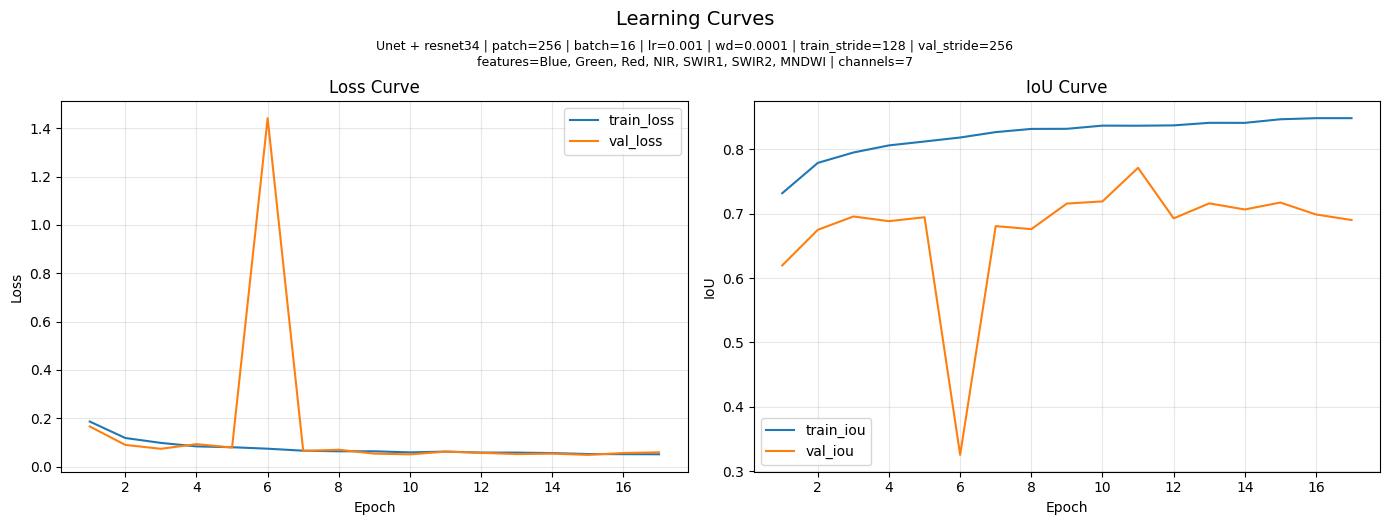

val metrics: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\val_metrics.csv
learning curves: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\learning_curves.png
confusion matrix: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\confusion_matrix.png
pr curve: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\precision_recall_curve.png


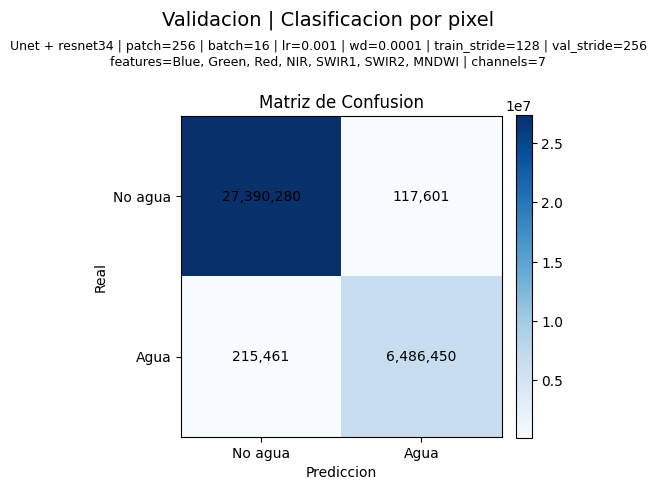

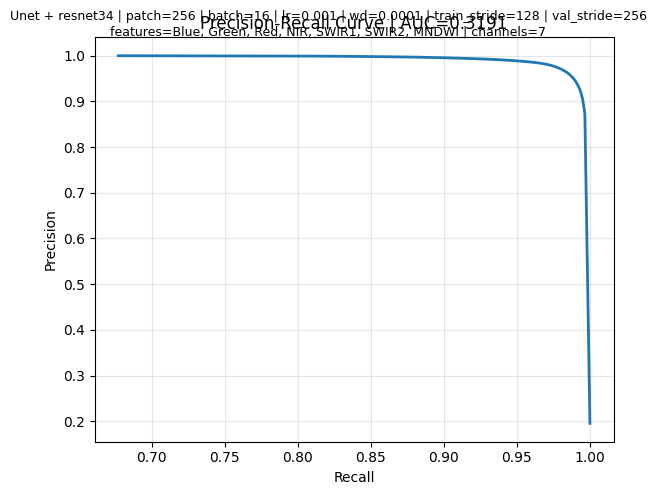

In [10]:
plot_learning_curves(history_df, cfg)

best_model_eval, _, _ = load_model_for_inference(cfg["model_path"], device)
val_metrics_cls, val_curves = evaluate_classification_metrics(val_loader, best_model_eval, threshold=0.5)

metrics_df = pd.DataFrame([val_metrics_cls])
metrics_df["experiment_name"] = cfg["experiment_name"]
metrics_df["architecture"] = cfg["architecture"]
metrics_df["encoder_name"] = cfg["encoder_name"]
metrics_df["band_ids"] = ",".join(map(str, cfg["band_ids"]))
metrics_df["band_names"] = ", ".join(cfg["band_names"])
metrics_df["spectral_indices"] = ", ".join(cfg["spectral_indices"])
metrics_df["input_features"] = ", ".join(cfg["input_features"])
metrics_df["input_channels"] = cfg["input_channels"]
metrics_df.to_csv(cfg["val_metrics_path"], index=False)
print("val metrics:", cfg["val_metrics_path"])
print("learning curves:", cfg["learning_curve_path"])
print("confusion matrix:", cfg["confusion_matrix_path"])
print("pr curve:", cfg["pr_curve_path"])
metrics_df[["threshold", "precision", "recall", "iou", "dice", "pr_auc", "tp", "tn", "fp", "fn"]]

plot_confusion_matrix(val_metrics_cls, cfg)
plot_precision_recall_curve(val_curves, val_metrics_cls, cfg)


## 11. Diagnostico Visual de un Parche de Validacion

Aqui se toma un parche aleatorio del conjunto de validacion para mirar la calidad de la segmentacion de una forma mas intuitiva.

### Que muestra

- Imagen RGB del parche.
- Mascara real.
- Prediccion binaria.
- Mapa de errores con `TP`, `FP` y `FN`.

Esto facilita para detectar problemas de bordes, sombras, ruido o cuerpos de agua pequenos.


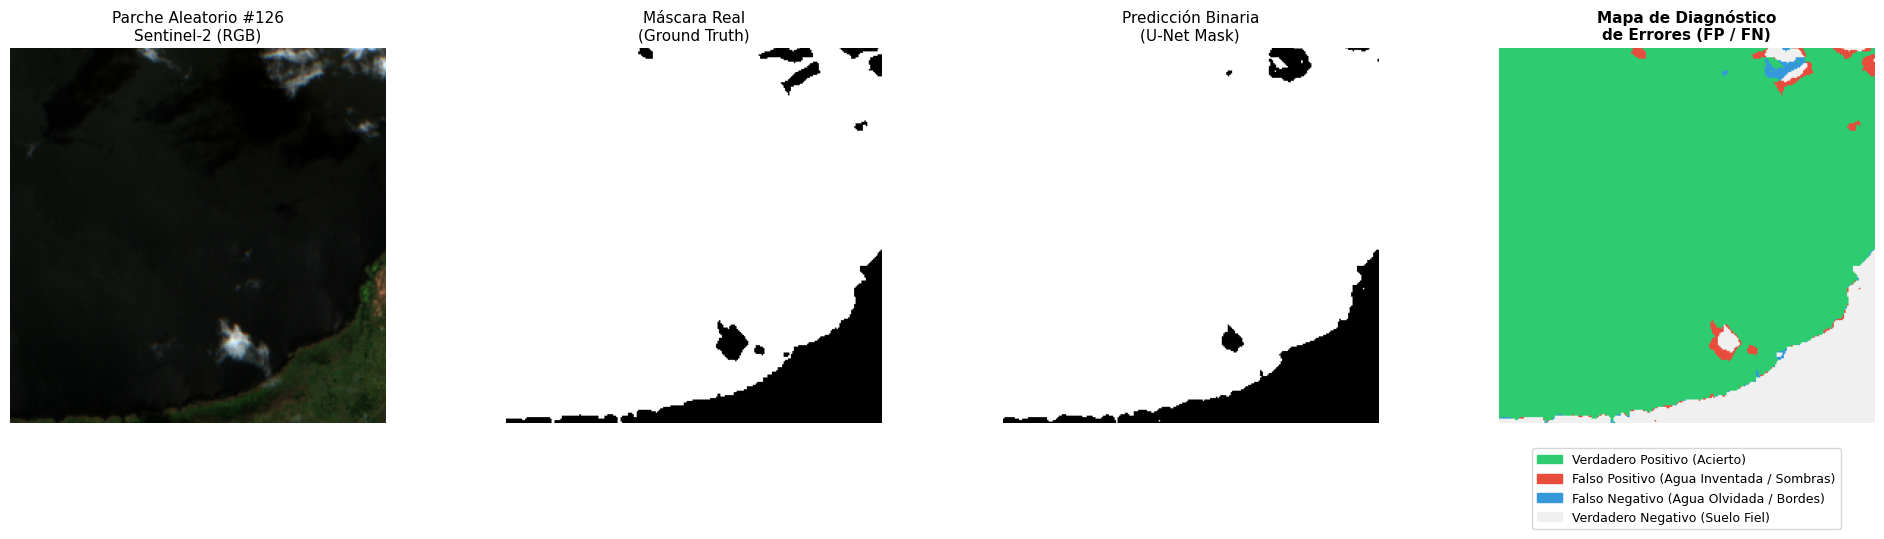

In [11]:
import random
import matplotlib.patches as mpatches

# 1. Seleccionar un índice aleatorio del dataset de validación
idx = random.randint(0, len(val_ds) - 1)
img_tensor, mask_tensor = val_ds[idx]

# 2. Preparar el tensor para el modelo (añadir dimensión de batch: [1, C, H, W])
x = img_tensor.unsqueeze(0).to(device)

# 3. Inferencia con el mejor modelo guardado
best_model_eval.eval()
with torch.no_grad():
    with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        logits = best_model_eval(x)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()
        pred = (prob > 0.5).astype(np.uint8)

# 4. Pasar la máscara real a matriz NumPy [H, W]
mask = mask_tensor.squeeze().numpy().astype(np.uint8)

# 5. Segmentación matemática de aciertos y errores (Matriz de Confusión por píxel)
tp = (pred == 1) & (mask == 1)  # Verdaderos Positivos (Agua bien detectada)
tn = (pred == 0) & (mask == 0)  # Verdaderos Negativos (Tierra bien detectada)
fp = (pred == 1) & (mask == 0)  # Falsos Positivos (Error: El modelo inventó agua)
fn = (pred == 0) & (mask == 1)  # Falsos Negativos (Error: El modelo olvidó el agua)

# 6. Construir el mapa visual de errores en formato RGB
# Inicializamos el fondo en gris claro para la tierra (TN)
error_map = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8) + 240

error_map[tp] = [46, 204, 113]   # Verde: Verdaderos Positivos
error_map[fp] = [231, 76, 60]    # Rojo: Falsos Positivos (FP)
error_map[fn] = [52, 152, 219]   # Azul: Falsos Negativos (FN)

# 7. Reconstrucción de la imagen Sentinel-2 en color real (RGB) con realce de brillo
r = img_tensor[2].numpy()
g = img_tensor[1].numpy()
b = img_tensor[0].numpy()
rgb = np.stack([r, g, b], axis=-1)
rgb = np.clip(rgb * 3.0, 0.0, 1.0) # Multiplicamos por 3 para aclarar la visualización

# 8. Graficar el cuarteto de diagnóstico visual
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Panel 1: Imagen Satelital
axes[0].imshow(rgb)
axes[0].set_title(f"Parche Aleatorio #{idx}\nSentinel-2 (RGB)", fontsize=11)
axes[0].axis("off")

# Panel 2: Ground Truth
axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Máscara Real\n(Ground Truth)", fontsize=11)
axes[1].axis("off")

# Panel 3: U-Net Prediction
axes[2].imshow(pred, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Predicción Binaria\n(U-Net Mask)", fontsize=11)
axes[2].axis("off")

# Panel 4: Mapa de Errores Clínico
axes[3].imshow(error_map)
axes[3].set_title("Mapa de Diagnóstico\nde Errores (FP / FN)", fontsize=11, fontweight="bold")
axes[3].axis("off")

# Crear leyendas personalizadas para el mapa de errores
legend_tp = mpatches.Patch(color='#2ECC71', label='Verdadero Positivo (Acierto)')
legend_fp = mpatches.Patch(color='#E74C3C', label='Falso Positivo (Agua Inventada / Sombras)')
legend_fn = mpatches.Patch(color='#3498DB', label='Falso Negativo (Agua Olvidada / Bordes)')
legend_tn = mpatches.Patch(color='#F0F0F0', label='Verdadero Negativo (Suelo Fiel)')
axes[3].legend(handles=[legend_tp, legend_fp, legend_fn, legend_tn], 
               loc='upper center', bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=True)

plt.tight_layout()
fig.savefig(cfg["experiment_dir"] / f"fp_fn_diagnosis_patch_{idx}.png", dpi=250, bbox_inches="tight")
plt.show()

## 12. Evaluacion en Test Externo (`part5`)

En esta parte se recorre cada escena de `part5`, se hace inferencia completa y se guardan resultados por escena y resultados agregados.

### Que deja guardado

- Mascara predicha por escena.
- `test_metrics_part5.csv`
- `test_global_metrics_part5.csv`



In [12]:
part5_scene_dirs = [p for p in sorted(PART5_DIR.glob("*")) if p.is_dir()]

best_model_test, band_ids_test, cfg_test = load_model_for_inference(cfg["model_path"], device)
test_rows = []

for scene_dir in part5_scene_dirs:
    metrics_scene, _, _, _, _ = evaluate_part5_scene(
        scene_dir=scene_dir,
        model=best_model_test,
        device=device,
        band_ids=band_ids_test,
        patch_size=cfg_test.get("patch_size", 256),
        stride=cfg_test.get("patch_size", 256),
        threshold=0.5,
        out_dir=cfg["test_dir"],
    )
    test_rows.append(metrics_scene)

test_metrics_df = pd.DataFrame(test_rows)
test_metrics_df["experiment_name"] = cfg["experiment_name"]
test_metrics_df["architecture"] = cfg["architecture"]
test_metrics_df["encoder_name"] = cfg["encoder_name"]
test_metrics_df["band_ids"] = ",".join(map(str, cfg["band_ids"]))
test_metrics_df["band_names"] = ", ".join(cfg["band_names"])
test_metrics_df["spectral_indices"] = ", ".join(cfg["spectral_indices"])
test_metrics_df["input_features"] = ", ".join(cfg["input_features"])
test_metrics_df["input_channels"] = cfg["input_channels"]
test_metrics_df.to_csv(cfg["test_metrics_path"], index=False)

tp = int(test_metrics_df["tp"].sum())
tn = int(test_metrics_df["tn"].sum())
fp = int(test_metrics_df["fp"].sum())
fn = int(test_metrics_df["fn"].sum())

global_metrics = {
    "experiment_name": cfg["experiment_name"],
    "threshold": 0.5,
    "precision": tp / max(tp + fp, 1),
    "recall": tp / max(tp + fn, 1),
    "iou": tp / max(tp + fp + fn, 1),
    "dice": (2 * tp) / max(2 * tp + fp + fn, 1),
    "tp": tp,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "n_scenes": len(test_metrics_df),
    "band_ids": ",".join(map(str, cfg["band_ids"])),
    "band_names": ", ".join(cfg["band_names"]),
    "spectral_indices": ", ".join(cfg["spectral_indices"]),
    "input_features": ", ".join(cfg["input_features"]),
    "input_channels": cfg["input_channels"],
}

test_global_metrics_df = pd.DataFrame([global_metrics])
test_global_metrics_df.to_csv(cfg["test_global_metrics_path"], index=False)

print("test per-scene metrics:", cfg["test_metrics_path"])
print("test global metrics:", cfg["test_global_metrics_path"])
test_metrics_df[["scene_id", "precision", "recall", "iou", "dice", "valid_pixels"]]


test per-scene metrics: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\test_part5\test_metrics_part5.csv
test global metrics: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\test_part5\test_global_metrics_part5.csv


,scene_id,precision,recall,iou,dice,valid_pixels
0,71,0.645752,0.942337,0.621205,0.766350,120455811
1,73,0.175407,0.999938,0.175405,0.298459,116614152
2,75,0.848860,0.999606,0.848576,0.918086,120432510
3,76,0.998318,0.999770,0.998088,0.999043,117418977
4,77,0.380829,0.998249,0.380575,0.551328,118671633
5,78,0.925453,0.970721,0.900322,0.947547,119876256
6,80,0.951002,0.999499,0.950548,0.974647,120343887
7,82,0.982390,0.999419,0.981829,0.990831,120269556


## 13. Graficas Globales del Test

Con las probabilidades reconstruidas del conjunto `part5`, esta celda resume el rendimiento global del test externo.

### Importante sobre tiempo de ejecucion

Para evitar recomputar toda la inferencia cada vez, este bloque ahora intenta leer los `prob_map` ya guardados dentro de `cfg["test_dir"]`. Si no existen, los calcula una sola vez y los deja cacheados para reutilizarlos despues.

### Que genera

- Matriz de confusion global.
- Curva precision-recall global.
- Una escena diagnostica representativa.

Es un buen bloque para comparar corridas cuando dos modelos se ven parecidos en validacion.



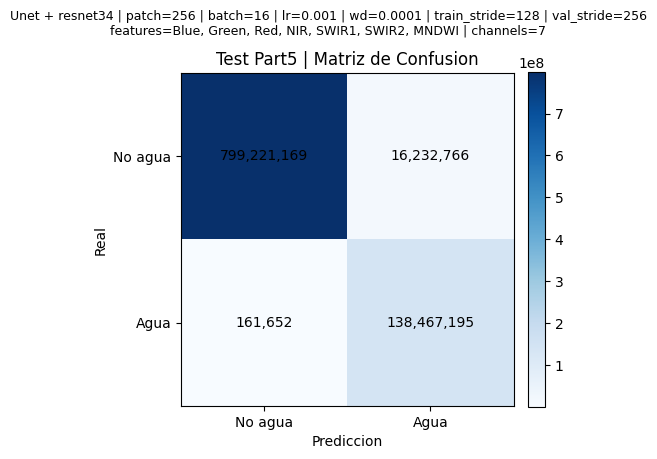

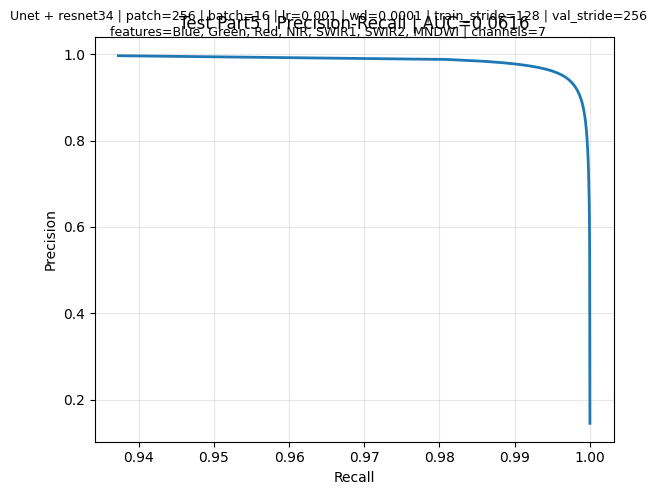

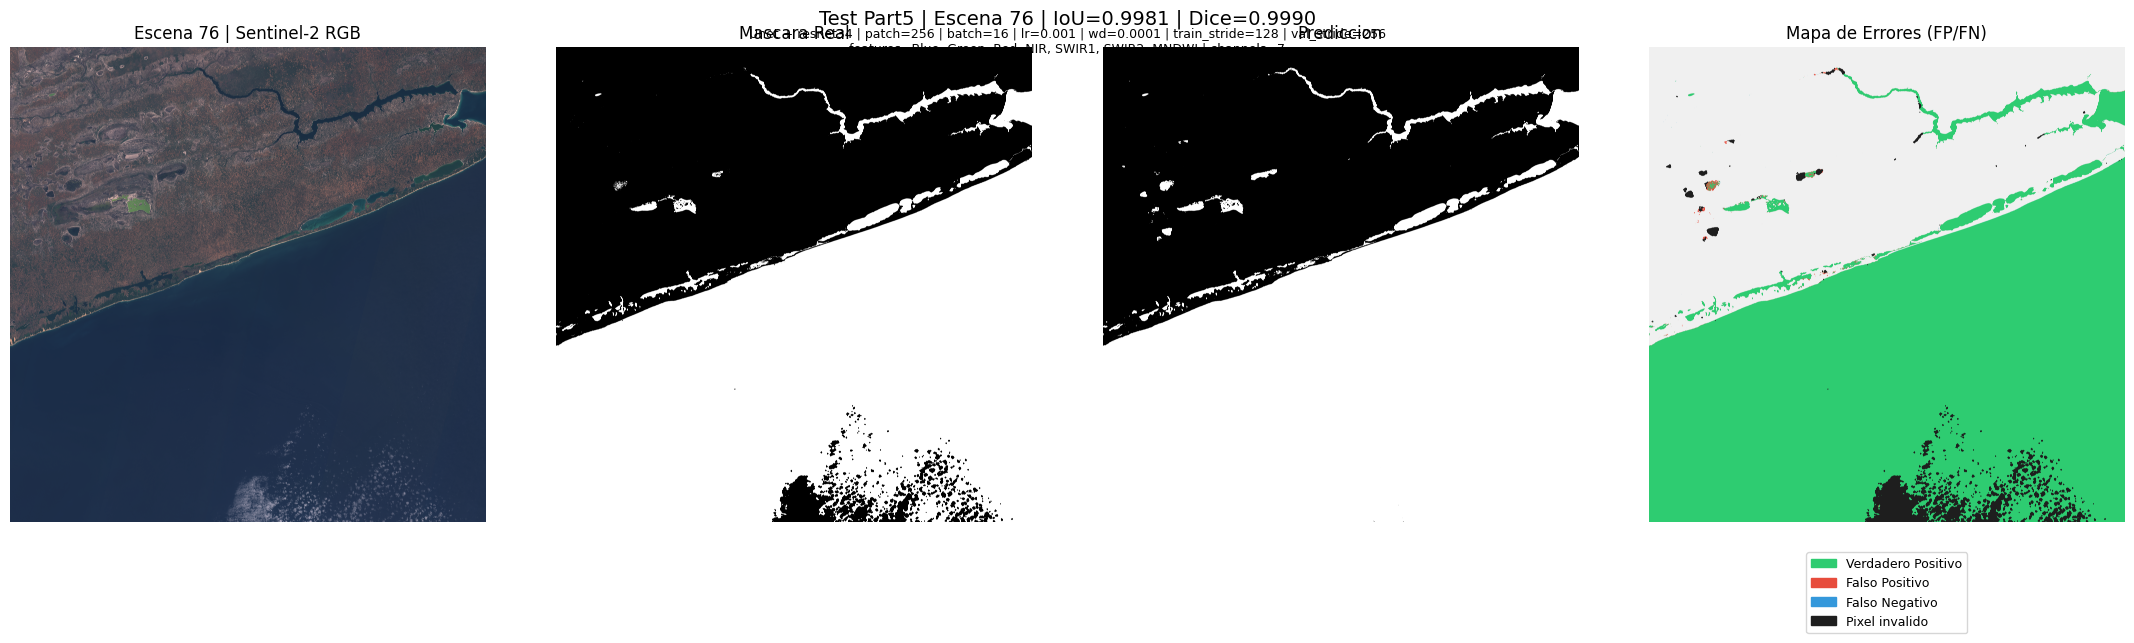

test confusion matrix: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\test_part5\test_confusion_matrix_part5.png
test pr curve: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\test_part5\test_precision_recall_curve_part5.png
test diagnostic scene: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\test_part5\test_scene_diagnostic_part5.png


In [13]:
y_prob_test, y_true_test = collect_part5_probabilities(
    scene_dirs=part5_scene_dirs,
    model=best_model_test,
    device=device,
    band_ids=band_ids_test,
    patch_size=cfg_test.get("patch_size", 256),
    stride=cfg_test.get("patch_size", 256),
    cache_dir=cfg["test_dir"],
)

test_global_cls_metrics, test_global_curves = build_metrics_from_probabilities(y_prob_test, y_true_test, threshold=0.5)
plot_test_confusion_matrix(test_global_cls_metrics, cfg)
plot_test_precision_recall_curve(test_global_curves, test_global_cls_metrics, cfg)

# Toma la escena con mejor IoU para dejar un ejemplo visual claro.
best_scene_id = test_metrics_df.sort_values("iou", ascending=False).iloc[0]["scene_id"]
best_scene_dir = PART5_DIR / str(best_scene_id)
plot_test_scene_diagnostics(best_scene_dir, best_model_test, device, band_ids_test, cfg, threshold=0.5)

print("test confusion matrix:", cfg["test_confusion_matrix_path"])
print("test pr curve:", cfg["test_pr_curve_path"])
print("test diagnostic scene:", cfg["test_diagnostic_scene_path"])
print("test probability cache dir:", cfg["test_dir"])



## 14. Ejemplo Final de Inferencia

Este ultimo bloque muestra el uso minimo del modelo entrenado sobre una escena concreta fuera del flujo de evaluacion.


In [14]:
model_inf, band_ids_inf, cfg_inf = load_model_for_inference(cfg["model_path"], device)

# Cambia esta ruta por cualquier Sentinel-2 .tif con las bandas esperadas.
img_path = DATA_DIR / "dset-s2" / "val_scene" / "S2A_L2A_20190318_N0211_R061_6Bands_S1.tif"
out_path = cfg["experiment_dir"] / "pred_mask_example.tif"

prob_map, pred_mask = predict_tif(
    img_path=img_path,
    model=model_inf,
    device=device,
    band_ids=band_ids_inf,
    patch_size=cfg_inf.get("patch_size", 256),
    stride=cfg_inf.get("patch_size", 256),
    threshold=0.5,
    out_path=out_path,
)

print("imagen:", img_path)
print("salida:", out_path)
print("shape prob:", prob_map.shape)
print("pixeles agua:", int(pred_mask.sum()))


imagen: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\data\dset-s2\val_scene\S2A_L2A_20190318_N0211_R061_6Bands_S1.tif
salida: c:\Users\Daniel Ortiz\OneDrive\Xcalibur\experiments\run_20260621_233116\pred_mask_example.tif
shape prob: (697, 754)
pixeles agua: 51162
